## Deep-dive into training with TensorFlow

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

### Define the model

In [5]:
# This model is basically a function which computes the value of
# wx+b and returns the value
class Model(object):
    def __init__(self):
        self.w = tf.Variable(2.0)
        self.b = tf.Variable(1.0)

    def __call__(self, x):
        return self.w * x + self.b

model = Model()

### Define a loss function

In [6]:
def loss(y_pred, y_true):
    return tf.reduce_mean(tf.square(y_pred - y_true))

### Construct a syntesized training dataset

In [7]:
# This is the final weight and bias which needs to be achieved after using gradient descent
true_w = 3.0
true_b = 2.0
num_examples = 1000

xs = tf.random.normal(shape=[num_examples])
ys = (true_w*xs) + true_b

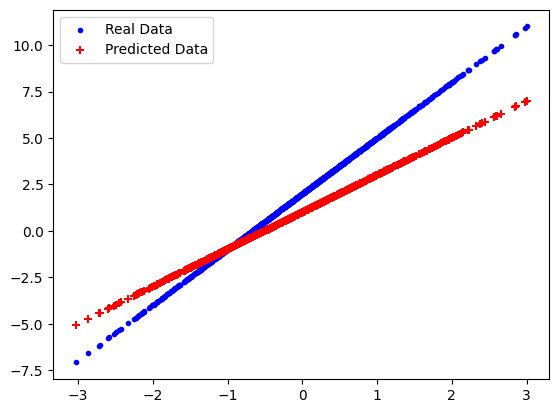

Current loss: 1.989612


In [10]:
def plot_data(inputs, outputs, predicted_outputs):
  real = plt.scatter(inputs, outputs, c='b', marker='.')
  predicted = plt.scatter(inputs, predicted_outputs, c='r', marker='+')
  plt.legend((real,predicted), ('Real Data', 'Predicted Data'))
  plt.show()

plot_data(xs, ys, model(xs))
print('Current loss: %1.6f' % loss(model(xs), ys).numpy())

### Define the training loop

In [12]:
def train(model, inputs, outputs, learning_rate):
    with tf.GradientTape() as tape:
        current_loss = loss(model(inputs), ys)
    # Find the gradient of current loss against the current weight and bias
    dw, db = tape.gradient(current_loss, [model.w, model.b])
    # Update the weight and bias values
    model.w.assign_sub(learning_rate * dw)
    model.b.assign_sub(learning_rate * db)

    return current_loss

In [14]:
# Call the training function recursively
model = Model()

list_w, list_b = [], []
epochs = range(15)
losses = []
for epoch in epochs:
   list_w.append(model.w.numpy())
   list_b.append(model.b.numpy())
   current_loss = train(model, xs, ys, learning_rate=0.1)
   losses.append(current_loss)
   print('Epoch %2d: w=%1.2f b=%1.2f, loss=%2.5f' %
         (epoch, list_w[-1], list_b[-1], current_loss))

Epoch  0: w=2.00 b=1.00, loss=1.98961
Epoch  1: w=2.20 b=1.20, loss=1.27665
Epoch  2: w=2.36 b=1.36, loss=0.81917
Epoch  3: w=2.48 b=1.49, loss=0.52563
Epoch  4: w=2.59 b=1.59, loss=0.33728
Epoch  5: w=2.67 b=1.67, loss=0.21642
Epoch  6: w=2.73 b=1.74, loss=0.13887
Epoch  7: w=2.79 b=1.79, loss=0.08911
Epoch  8: w=2.83 b=1.83, loss=0.05718
Epoch  9: w=2.86 b=1.87, loss=0.03669
Epoch 10: w=2.89 b=1.89, loss=0.02355
Epoch 11: w=2.91 b=1.91, loss=0.01511
Epoch 12: w=2.93 b=1.93, loss=0.00970
Epoch 13: w=2.94 b=1.95, loss=0.00622
Epoch 14: w=2.95 b=1.96, loss=0.00399


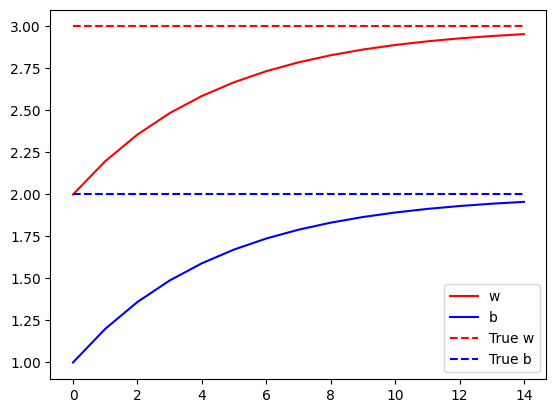

In [16]:
plt.plot(epochs, list_w, 'r',
       epochs, list_b, 'b')
plt.plot([true_w] * len(epochs), 'r--',
      [true_b] * len(epochs), 'b--')
plt.legend(['w', 'b', 'True w', 'True b'])
plt.show()